In [1]:
from google.colab import files

uploaded = files.upload()

Saving cardekho_dataset.csv to cardekho_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# %matplotlib inline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

In [3]:
df=pd.read_csv('cardekho_dataset.csv',index_col=0)

In [4]:
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [5]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.6+ MB


In [7]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [8]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.0000,15411.0000,15411.0000,15411.0000,15411.0000,15411.0000,15411.0000
mean,6.0363,55616.4806,19.7012,1486.0578,100.5883,5.3255,774971.1164
std,3.0133,51618.5484,4.1713,521.1067,42.9730,0.8076,894128.3633
min,0.0000,100.0000,4.0000,793.0000,38.4000,0.0000,40000.0000
25%,4.0000,30000.0000,17.0000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,556000.0000
75%,8.0000,70000.0000,22.7000,1582.0000,117.3000,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,39500000.0000


In [9]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0
engine,0


In [10]:
df.drop(columns=['car_name','brand'],inplace=True)

In [11]:
num_features=[feature for feature in df.columns if df[feature].dtype!='O']
cat_features=[feature for feature in df.columns if df[feature].dtype=='O']
discrete_features_15=[feature for feature in num_features if len(df[feature].unique())<=15]
discrete_features_30=[feature for feature in num_features if len(df[feature].unique())<=30 & len(df[feature].unique())>15]
continuous_features=[feature for feature in num_features if len(df[feature].unique())>30]
print('Numerical Features:',num_features)
print('Categorical Features:',cat_features)
print('Discrete Features(less than 15):',discrete_features_15)
print('Discrete Features(less than 30 greater than 15):',discrete_features_30)
print('Continuous Features:',continuous_features)

Numerical Features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Categorical Features: ['model', 'seller_type', 'fuel_type', 'transmission_type']
Discrete Features(less than 15): ['seats']
Discrete Features(less than 30 greater than 15): ['vehicle_age']
Continuous Features: ['km_driven', 'mileage', 'engine', 'max_power', 'selling_price']


In [12]:
print('Number of Numerical Features:',len(num_features))
print('Number of Categorical Features:',len(cat_features))
print('Number of Discrete Features(less than 15):',len(discrete_features_15))
print('Number of Discrete Features(less than 30 greater than 15):',len(discrete_features_30))
print('Number of Continuous Features:',len(continuous_features))

Number of Numerical Features: 7
Number of Categorical Features: 4
Number of Discrete Features(less than 15): 1
Number of Discrete Features(less than 30 greater than 15): 1
Number of Continuous Features: 5


In [13]:
df

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Alto,9,120000,Individual,Petrol,Manual,19.7000,796,46.3000,5,120000
1,Grand,5,20000,Individual,Petrol,Manual,18.9000,1197,82.0000,5,550000
2,i20,11,60000,Individual,Petrol,Manual,17.0000,1197,80.0000,5,215000
3,Alto,9,37000,Individual,Petrol,Manual,20.9200,998,67.1000,5,226000
4,Ecosport,6,30000,Dealer,Diesel,Manual,22.7700,1498,98.5900,5,570000
...,...,...,...,...,...,...,...,...,...,...,...
19537,i10,9,10723,Dealer,Petrol,Manual,19.8100,1086,68.0500,5,250000
19540,Ertiga,2,18000,Dealer,Petrol,Manual,17.5000,1373,91.1000,7,925000
19541,Rapid,6,67000,Dealer,Diesel,Manual,21.1400,1498,103.5200,5,425000
19542,XUV500,5,3800000,Dealer,Diesel,Manual,16.0000,2179,140.0000,7,1225000


In [14]:
for feature in cat_features:
    print(df[feature].value_counts())


model
i20             906
Swift Dzire     890
Swift           781
Alto            778
City            757
               ... 
Altroz            1
C                 1
Ghost             1
Quattroporte      1
Gurkha            1
Name: count, Length: 120, dtype: int64
seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64
fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64
transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64


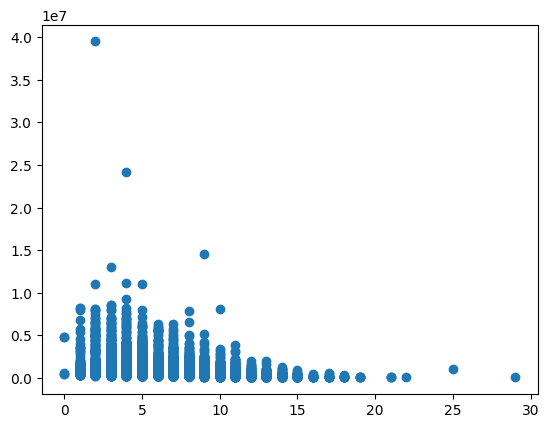

In [15]:
plt.scatter(df['vehicle_age'],df['selling_price'])

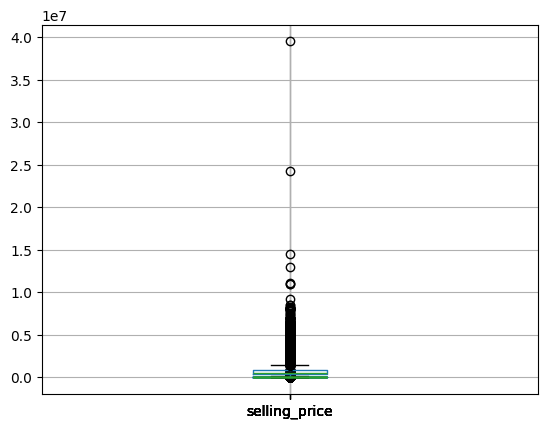

In [16]:
for feature in num_features:
    df.boxplot(column=feature)

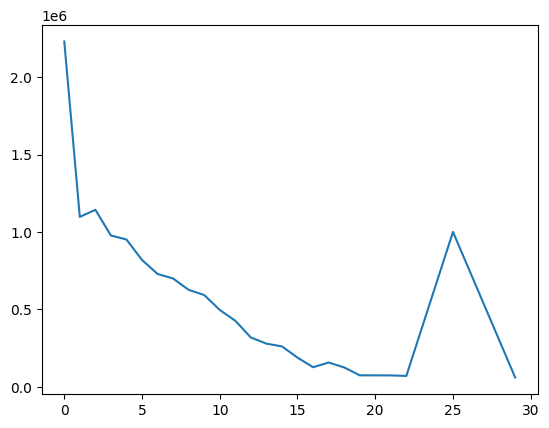

In [17]:
avg_price=df.groupby('vehicle_age')['selling_price'].mean()
plt.plot(avg_price.index,avg_price)

(array([1.5192e+04, 1.9700e+02, 1.8000e+01, 2.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([   40000.,  3986000.,  7932000., 11878000., 15824000., 19770000.,
        23716000., 27662000., 31608000., 35554000., 39500000.]),
 <BarContainer object of 10 artists>)

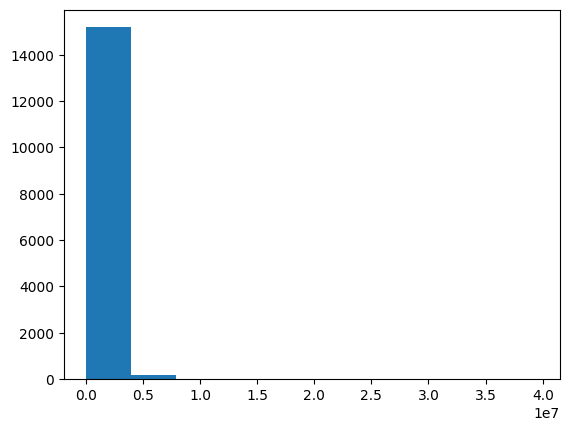

In [18]:
plt.hist(df['selling_price'],bins=10)

In [19]:
df['selling_price'].max()

39500000

In [21]:
X=df.drop(columns=['selling_price'])
y=df['selling_price']

In [23]:
le=LabelEncoder()
X['model']=le.fit_transform(X['model'])

In [24]:
le.inverse_transform([119])

array(['redi-GO'], dtype=object)

In [25]:
df[df['model']=='redi-GO']

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
2134,redi-GO,3,5986,Dealer,Petrol,Automatic,22.0000,999,67.0500,5,375000
6834,redi-GO,3,6000,Dealer,Petrol,Automatic,22.0000,999,67.0500,5,435000
7352,redi-GO,4,34000,Dealer,Petrol,Manual,21.7000,999,67.0500,5,249000
8797,redi-GO,4,50500,Dealer,Petrol,Manual,20.7100,799,53.6400,5,250000
10249,redi-GO,1,10000,Dealer,Petrol,Manual,20.7100,799,53.6400,5,349000
10933,redi-GO,3,2300,Dealer,Petrol,Manual,20.7100,799,53.6400,5,325000
12350,redi-GO,5,47000,Dealer,Petrol,Manual,20.7100,799,53.6400,5,299000
13191,redi-GO,5,50000,Dealer,Petrol,Manual,21.7000,999,67.0500,5,325000
14255,redi-GO,4,17000,Dealer,Petrol,Manual,20.7100,799,53.6400,5,280000
16093,redi-GO,5,7001,Dealer,Petrol,Manual,21.7000,999,67.0500,5,325000


In [26]:
le.classes_

array(['3', '5', '6', '7', 'A4', 'A6', 'A8', 'Alto', 'Altroz', 'Alturas',
       'Amaze', 'Aspire', 'Aura', 'Baleno', 'Bolero', 'C', 'C-Class',
       'CLS', 'CR', 'CR-V', 'Camry', 'Carnival', 'Cayenne', 'Celerio',
       'Ciaz', 'City', 'Civic', 'Compass', 'Continental', 'Cooper',
       'Creta', 'D-Max', 'Duster', 'Dzire LXI', 'Dzire VXI', 'Dzire ZXI',
       'E-Class', 'ES', 'Ecosport', 'Eeco', 'Elantra', 'Endeavour',
       'Ertiga', 'F-PACE', 'Figo', 'Fortuner', 'Freestyle', 'GL-Class',
       'GLS', 'GO', 'GTC4Lusso', 'Ghibli', 'Ghost', 'Glanza', 'Grand',
       'Gurkha', 'Harrier', 'Hector', 'Hexa', 'Ignis', 'Innova', 'Jazz',
       'KUV', 'KUV100', 'KWID', 'Kicks', 'MUX', 'Macan', 'Marazzo', 'NX',
       'Nexon', 'Octavia', 'Panamera', 'Polo', 'Q7', 'Quattroporte', 'RX',
       'Rapid', 'RediGO', 'Rover', 'S-Class', 'S-Presso', 'S90', 'Safari',
       'Santro', 'Scorpio', 'Seltos', 'Superb', 'Swift', 'Swift Dzire',
       'Thar', 'Tiago', 'Tigor', 'Triber', 'Tucson', 'Vento', '

In [27]:
import pandas as pd

label_mapping = pd.DataFrame({
    'Label': le.classes_,
    'Encoded_Value': range(len(le.classes_)),
    'Count': df['model'].value_counts().sort_index().values
})

label_mapping


,Label,Encoded_Value,Count
0,3,0,152
1,5,1,118
2,6,2,18
3,7,3,37
4,A4,4,99
...,...,...,...
115,Yaris,115,17
116,Z4,116,6
117,i10,117,410
118,i20,118,906


In [28]:
le.transform(['i20'])

array([118])

In [29]:
onehot=OneHotEncoder(drop='first')
scaler=StandardScaler()

onehot_columns=['seller_type', 'fuel_type', 'transmission_type']
num_features=X.select_dtypes(exclude='object').columns
preprocessor=ColumnTransformer(
    transformers=[
        ('OneHotEncoder',onehot,onehot_columns),
        ('StandardScaler',scaler,num_features)
    ],remainder='passthrough'
)

In [30]:
X

,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,7,9,120000,Individual,Petrol,Manual,19.7000,796,46.3000,5
1,54,5,20000,Individual,Petrol,Manual,18.9000,1197,82.0000,5
2,118,11,60000,Individual,Petrol,Manual,17.0000,1197,80.0000,5
3,7,9,37000,Individual,Petrol,Manual,20.9200,998,67.1000,5
4,38,6,30000,Dealer,Diesel,Manual,22.7700,1498,98.5900,5
...,...,...,...,...,...,...,...,...,...,...
19537,117,9,10723,Dealer,Petrol,Manual,19.8100,1086,68.0500,5
19540,42,2,18000,Dealer,Petrol,Manual,17.5000,1373,91.1000,7
19541,77,6,67000,Dealer,Diesel,Manual,21.1400,1498,103.5200,5
19542,114,5,3800000,Dealer,Diesel,Manual,16.0000,2179,140.0000,7


In [31]:
X=preprocessor.fit_transform(X)

In [32]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-1.5197,0.9836,1.2473,-0.0003,-1.3243,-1.2634,-0.4030
1,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.2257,-0.3439,-0.6900,-0.1921,-0.5547,-0.4326,-0.4030
2,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.5364,1.6473,0.0849,-0.6476,-0.5547,-0.4791,-0.4030
3,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-1.5197,0.9836,-0.3607,0.2922,-0.9366,-0.7793,-0.4030
4,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,-0.6662,-0.0121,-0.4963,0.7357,0.0229,-0.0465,-0.4030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.5088,0.9836,-0.8697,0.0261,-0.7677,-0.7572,-0.4030
15407,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,-0.5561,-1.3396,-0.7288,-0.5277,-0.2170,-0.2208,2.0734
15408,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.4076,-0.0121,0.2205,0.3450,0.0229,0.0682,-0.4030
15409,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.4262,-0.3439,72.5419,-0.8873,1.3298,0.9172,2.0734


In [33]:
df['fuel_type'].value_counts()

,count
fuel_type,
Petrol,7643
Diesel,7419
CNG,301
LPG,44
Electric,4


In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [36]:
def evaluate_model(true,predicted):
    mse=mean_squared_error(true,predicted)
    mae=mean_absolute_error(true,predicted)
    rmse=root_mean_squared_error(true,predicted)
    r2=r2_score(true,predicted)
    return mae,mse,rmse,r2

In [37]:
models={
    "linear":LinearRegression(),
    "lasso":Lasso(),
    "ridge":Ridge(),
    "knn":KNeighborsRegressor(),
    "rf":RandomForestRegressor(),
    "dt":DecisionTreeRegressor(),
    "ab":AdaBoostRegressor(),
}

In [38]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    print(model)

LinearRegression()
Lasso()
Ridge()
KNeighborsRegressor()
RandomForestRegressor()
DecisionTreeRegressor()
AdaBoostRegressor()


In [40]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae,  test_mse,  test_rmse,  test_r2  = evaluate_model(y_test, y_test_pred)

    print("=" * 60)
    print(f"Model: {model}")
    print("-" * 60)

    print("Train Metrics:")
    print(f"  MAE  : {train_mae:.4f}")
    print(f"  MSE  : {train_mse:.4f}")
    print(f"  RMSE : {train_rmse:.4f}")
    print(f"  R2   : {train_r2:.4f}")

    print("\nTest Metrics:")
    print(f"  MAE  : {test_mae:.4f}")
    print(f"  MSE  : {test_mse:.4f}")
    print(f"  RMSE : {test_rmse:.4f}")
    print(f"  R2   : {test_r2:.4f}")


Model: LinearRegression()
------------------------------------------------------------
Train Metrics:
  MAE  : 260031.9512
  MSE  : 229251209296.3019
  RMSE : 478801.8476
  R2   : 0.6763

Test Metrics:
  MAE  : 280915.9804
  MSE  : 567633907510.6738
  RMSE : 753414.8310
  R2   : 0.5123
Model: Lasso()
------------------------------------------------------------
Train Metrics:
  MAE  : 260030.0543
  MSE  : 229251214150.1726
  RMSE : 478801.8527
  R2   : 0.6763

Test Metrics:
  MAE  : 280914.8656
  MSE  : 567632802563.0322
  RMSE : 753414.0977
  R2   : 0.5123
Model: Ridge()
------------------------------------------------------------
Train Metrics:
  MAE  : 260001.4870
  MSE  : 229251876065.9362
  RMSE : 478802.5439
  R2   : 0.6763

Test Metrics:
  MAE  : 280894.8976
  MSE  : 567653596621.1935
  RMSE : 753427.8974
  R2   : 0.5122
Model: KNeighborsRegressor()
------------------------------------------------------------
Train Metrics:
  MAE  : 88382.2051
  MSE  : 53905417575.5901
  RMSE : 2

In [49]:
knn_params={'n_neighbors':[2,3,4,5,6,7,8,9,10,15,20,25,30,40]}
rf_params={
    'max_depth':[3,5,10,None,15],
    'max_features':['sqrt','log2',None,1,3,5],
    'min_samples_split':[2,5,15,20],
    'n_estimators':[100,200,350,500]
}
adaboost_params={
    'n_estimators':[40,50,60,70,80,90],
    'loss':['linear','square','exponential']
}

In [50]:
randomcv_models=[
    ('knn',KNeighborsRegressor(),knn_params),
    ('rf',RandomForestRegressor(),rf_params),
    ('ab',AdaBoostRegressor(),adaboost_params)
]

In [56]:
model_params={}
for name,model,params in randomcv_models:
    random=GridSearchCV(estimator=model,param_grid=params,cv=3,verbose=2,n_jobs=-1)
    random.fit(X_train,y_train)
    model_params[name]=random.best_params_

Fitting 3 folds for each of 14 candidates, totalling 42 fits
Fitting 3 folds for each of 480 candidates, totalling 1440 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 3 folds for each of 18 candidates, totalling 54 fits


In [58]:
for model_name in model_params:
    print(model_name,model_params[model_name])

knn {'n_neighbors': 2}
rf {'max_depth': 15, 'max_features': 5, 'min_samples_split': 2, 'n_estimators': 350}
ab {'loss': 'linear', 'n_estimators': 40}


In [59]:
model_params

{'knn': {'n_neighbors': 2},
 'rf': {'max_depth': 15,
  'max_features': 5,
  'min_samples_split': 2,
  'n_estimators': 350},
 'ab': {'loss': 'linear', 'n_estimators': 40}}

In [71]:
knn= {'n_neighbors': 2}
rf= {'n_estimators': 350,
  'min_samples_split': 2,
  'max_features': 5,
  'max_depth': 15}
ab= {'n_estimators': 40, 'loss': 'linear'}

In [74]:
models={
    "rf":RandomForestRegressor(n_estimators=350,
                               min_samples_split=2,
                               max_features= 5,
                               max_depth= 15),

    "knn":KNeighborsRegressor(n_neighbors=2),

    "ab":AdaBoostRegressor(n_estimators=40,loss='linear')
}

In [75]:
for model in models.values():
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae,  test_mse,  test_rmse,  test_r2  = evaluate_model(y_test, y_test_pred)

    print("=" * 60)
    print(f"Model: {model}")
    print("-" * 60)

    print("Train Metrics:")
    print(f"  MAE  : {train_mae:.4f}")
    print(f"  MSE  : {train_mse:.4f}")
    print(f"  RMSE : {train_rmse:.4f}")
    print(f"  R2   : {train_r2:.4f}")

    print("\nTest Metrics:")
    print(f"  MAE  : {test_mae:.4f}")
    print(f"  MSE  : {test_mse:.4f}")
    print(f"  RMSE : {test_rmse:.4f}")
    print(f"  R2   : {test_r2:.4f}")


Model: RandomForestRegressor(max_depth=15, max_features=5, n_estimators=350)
------------------------------------------------------------
Train Metrics:
  MAE  : 54632.6534
  MSE  : 10744635851.0246
  RMSE : 103656.3353
  R2   : 0.9848

Test Metrics:
  MAE  : 105821.3133
  MSE  : 282535553525.6082
  RMSE : 531540.7355
  R2   : 0.7572
Model: KNeighborsRegressor(n_neighbors=2)
------------------------------------------------------------
Train Metrics:
  MAE  : 62537.1867
  MSE  : 29359612929.8523
  RMSE : 171346.4704
  R2   : 0.9585

Test Metrics:
  MAE  : 120942.7506
  MSE  : 305915761028.2192
  RMSE : 553096.5205
  R2   : 0.7371
Model: AdaBoostRegressor(n_estimators=40)
------------------------------------------------------------
Train Metrics:
  MAE  : 283689.8994
  MSE  : 159343423125.1295
  RMSE : 399178.4352
  R2   : 0.7750

Test Metrics:
  MAE  : 293256.6342
  MSE  : 421114241627.6940
  RMSE : 648933.1565
  R2   : 0.6382


In [76]:
models={
    "rf":RandomForestRegressor(n_estimators=1000,
                               min_samples_split=2,
                               max_features= 5,
                               max_depth= 15),

    "knn":KNeighborsRegressor(n_neighbors=2),
    "ab":AdaBoostRegressor(n_estimators=40,loss='linear')

}

In [77]:
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae,  test_mse,  test_rmse,  test_r2  = evaluate_model(y_test, y_test_pred)

    print("=" * 60)
    print(f"Model: {model}")
    print("-" * 60)

    print("Train Metrics:")
    print(f"  MAE  : {train_mae:.4f}")
    print(f"  MSE  : {train_mse:.4f}")
    print(f"  RMSE : {train_rmse:.4f}")
    print(f"  R2   : {train_r2:.4f}")

    print("\nTest Metrics:")
    print(f"  MAE  : {test_mae:.4f}")
    print(f"  MSE  : {test_mse:.4f}")
    print(f"  RMSE : {test_rmse:.4f}")
    print(f"  R2   : {test_r2:.4f}")


Model: RandomForestRegressor(max_depth=15, max_features=5, n_estimators=1000)
------------------------------------------------------------
Train Metrics:
  MAE  : 54369.2208
  MSE  : 10712086795.1505
  RMSE : 103499.2116
  R2   : 0.9849

Test Metrics:
  MAE  : 105095.7607
  MSE  : 285085994850.4495
  RMSE : 533934.4481
  R2   : 0.7550
Model: KNeighborsRegressor(n_neighbors=2)
------------------------------------------------------------
Train Metrics:
  MAE  : 62537.1867
  MSE  : 29359612929.8523
  RMSE : 171346.4704
  R2   : 0.9585

Test Metrics:
  MAE  : 120942.7506
  MSE  : 305915761028.2192
  RMSE : 553096.5205
  R2   : 0.7371
Model: AdaBoostRegressor(n_estimators=40)
------------------------------------------------------------
Train Metrics:
  MAE  : 275416.4263
  MSE  : 155873263357.6522
  RMSE : 394807.8816
  R2   : 0.7799

Test Metrics:
  MAE  : 286154.8675
  MSE  : 396348486033.2043
  RMSE : 629562.1383
  R2   : 0.6594
